In [1]:
import numpy as np
import pandas as pd
from tqdm import trange
import matplotlib.pyplot as plt
import dfgen
from norm import norm
import os

In [2]:
folder_name = input('请输入保存模型的文件夹名称（若不存在则新建）')

请输入保存模型的文件夹名称（若不存在则新建）model10


In [3]:
# 对比结果等的存储路径
result_path = '../result/'
# 训练好的模型保存路径
model_path = '../trained_model/'

In [4]:
if not os.path.exists(result_path + folder_name):
    os.mkdir(result_path + folder_name)
    #创建几个子文件夹
    os.mkdir(result_path + folder_name + '/fuds')
    os.mkdir(result_path + folder_name + '/dst')
    os.mkdir(result_path + folder_name + '/us06')
    os.mkdir(result_path + folder_name + '/bjdst')

In [5]:
if not os.path.exists(model_path + folder_name):
    os.mkdir(model_path + folder_name)
    #子文件夹
    os.mkdir(model_path + folder_name + '/train')
    os.mkdir(model_path + folder_name + '/weights')
    os.mkdir(model_path + folder_name + '/param')

In [6]:
data_path = '../../data/net_data/'
param_path = '../../bat_mod/result/param.xlsx'
save_path = model_path + folder_name
seq_len = 30

In [7]:
sigma_p = 0.005
adp_noise=False
sigma_iu = 0.001
adp_iu = True

In [8]:
readme = '\
本模型为soc噪声0.05的多特征模型,ui噪声为1%'
file = open(save_path+'/readme.txt', 'w')
file.write(readme)
file.close()

训练数据的产生分以下几步：  
1. 在数据特征中添加前一时刻的soc
2. 将数据按时间步划分
3. 给数据的特征添加噪声
4. 将数据输入特征构造模块
5. 将数据进行归一化

导入数据

In [9]:
data1 = pd.read_excel(data_path + 'SP2_25C_FUDS/fuds_80.xlsx').values
data2 = pd.read_excel(data_path + 'SP2_25C_DST/dst_80.xlsx').values
data3 = pd.read_excel(data_path + 'SP2_25C_BJDST/bjdst_80.xlsx').values
data4 = pd.read_excel(data_path + 'SP2_25C_US06/us06_80.xlsx').values
data5 = pd.read_excel(data_path + 'OTHER_DATA/incre.xlsx').values

添加前一时刻的soc

In [10]:
def add_presoc(data):
    soc_pre = np.insert(data[:-1, -1], 0, data[0, -1]) 
    data_new = np.concatenate((soc_pre.reshape(-1, 1), data), axis=1) 
    return data_new

In [11]:
data1_new = add_presoc(data1)
data2_new = add_presoc(data2)
data3_new = add_presoc(data3)
data4_new = add_presoc(data4)
data5_new = add_presoc(data5)

In [12]:
print(data1_new.shape)

(11818, 4)


将数据按时间步划分

In [13]:
def split(data, seq_len): 
    """交替划分"""
    data1 = []
    for i in range(len(data) - seq_len):
        data1.append(data[i: i + seq_len, :])
    data2 = np.array(data1)
    """划分x和y"""
    x = np.round(data2[:, :, 1:-1] * 1000)
    soc_pre = data2[:, 0, 0]
    y = data2[:, -1, -1]
    data_dict = {'iu': x, 'soc_ini': soc_pre, 'soc_real': y}  
    return data_dict

In [14]:
data_dict1 = split(data1_new, seq_len=seq_len)
data_dict2 = split(data2_new, seq_len=seq_len)
data_dict3 = split(data3_new, seq_len=seq_len)
data_dict4 = split(data4_new, seq_len=seq_len)
data_dict5 = split(data5_new, seq_len=seq_len)

In [15]:
data_dict = {}
for key in data_dict1.keys():
    data_dict[key] = np.concatenate((data_dict1[key], \
                                data_dict2[key], \
                                data_dict3[key], \
                                data_dict4[key], \
                                data_dict5[key]), axis=0)

In [16]:
print(data_dict['iu'].shape)
print(data_dict['soc_ini'].shape)
print(data_dict['soc_real'].shape)

(209874, 30, 2)
(209874,)
(209874,)


给划分好的数据添加噪声

In [17]:
import add_noise

In [18]:
iu_noise = np.zeros(data_dict['iu'].shape) 
for i in trange(data_dict['iu'].shape[0]):    
    iu_noise[i, :, :] = add_noise.add_noise_iu(data_dict['iu'][i, :, :], sigma_iu=sigma_iu, adp_iu=adp_iu)

100%|██████████████████████████████████| 209874/209874 [00:20<00:00, 10391.74it/s]


In [19]:
soc_noise = add_noise.add_noise_s(data_dict['soc_ini'], sigma_p=sigma_p, adp_noise=adp_noise)
for i in range(len(soc_noise)):
    if soc_noise[i]>1:
        soc_noise[i] = 1
    elif soc_noise[i]<0:
        soc_noise[i] = 0

In [20]:
print(iu_noise.shape)
print(soc_noise.shape)

(209874, 30, 2)
(209874,)


soc添加噪声对比

In [21]:
noise1 = soc_noise - data_dict['soc_ini']

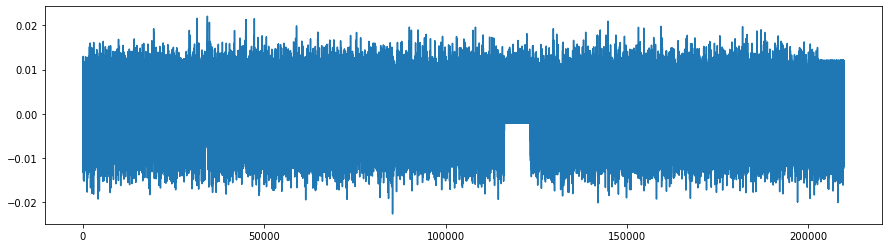

In [22]:
plt.figure(figsize=(15, 4))
plt.plot(noise1)
plt.show()

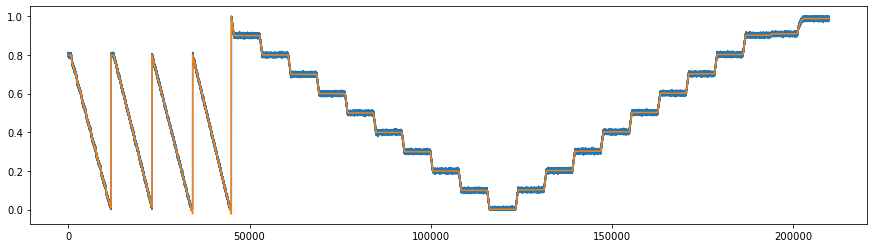

In [23]:
plt.figure(figsize=(15, 4))
plt.plot(soc_noise)
plt.plot(data_dict['soc_ini'])
plt.show()

电流添加噪声对比

In [24]:
noise2 = iu_noise[:, 0, 0] - data_dict['iu'][:, 0, 0]

In [25]:
noise2

array([-2.12255619,  0.        ,  0.        , ...,  0.        ,
        0.        ,  0.        ])

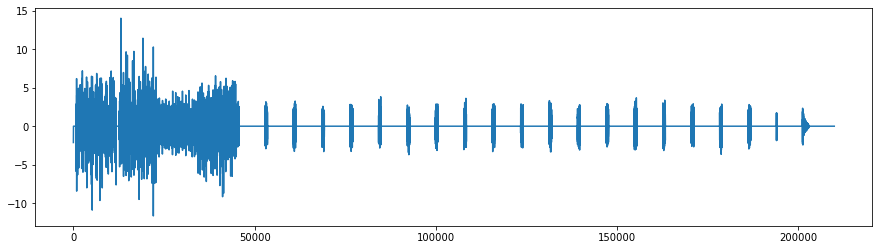

In [26]:
plt.figure(figsize=(15, 4))
plt.plot(noise2)
plt.show()

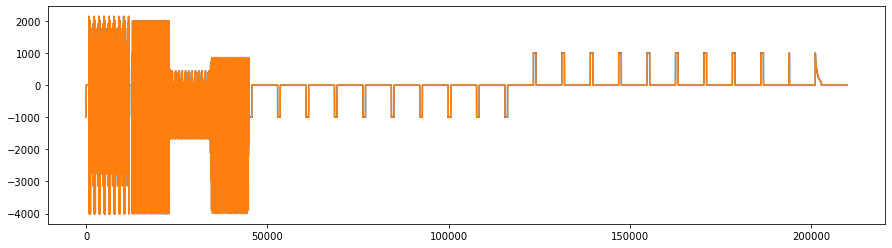

In [27]:
plt.figure(figsize=(15,4))
plt.plot(iu_noise[:, 0, 0])
plt.plot(data_dict['iu'][:, 0, 0])
plt.show()

电压添加噪声

In [28]:
noise3 = iu_noise[:, 0, 1] - data_dict['iu'][:, 0, 1]

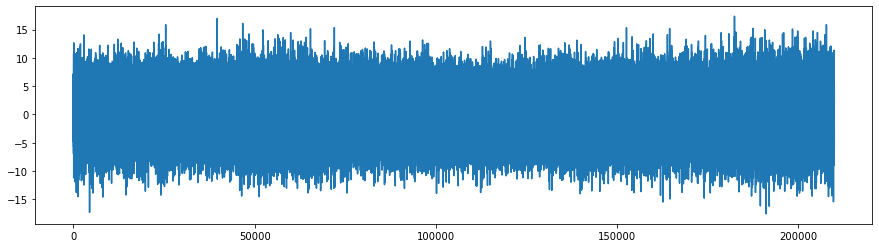

In [29]:
plt.figure(figsize=(15, 4))
plt.plot(noise3)
plt.show()

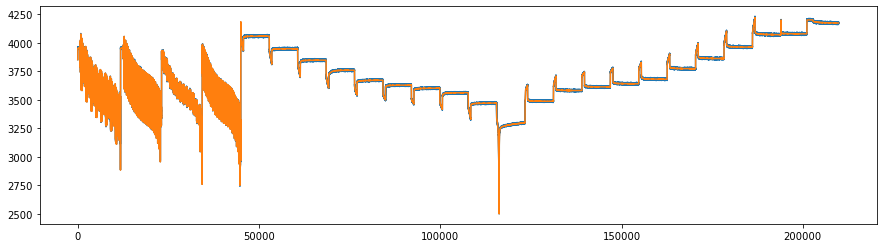

In [30]:
plt.figure(figsize=(15,4))
plt.plot(iu_noise[:, 0, 1])
plt.plot(data_dict['iu'][:, 0, 1])
plt.show()

保存结果

In [31]:
data_dict['iu'][:,0 ,1].shape

(209874,)

In [32]:
noise1.shape

(209874,)

In [33]:
col0 = data_dict['soc_ini'].reshape(-1,1)
col1 = soc_noise.reshape(-1,1)
col2 = noise1.reshape(-1,1)
col3 = data_dict['iu'][:,0,0].reshape(-1,1)
col4 = iu_noise[:, 0, 0].reshape(-1,1)
col5 = noise2.reshape(-1,1)
col6 = data_dict['iu'][:, 0, 1].reshape(-1,1)
col7 = iu_noise[:, 0, 1].reshape(-1,1)
col8 = noise3.reshape(-1,1)

In [34]:
data_temp = np.concatenate((col0, col1, col2, col3, col4, col5, col6, col7, col8),axis=1)
data_noise_compare = pd.DataFrame(data_temp)
data_noise_compare.to_excel(save_path + '/data_noise_compare_' + str(sigma_p)+ '.xlsx')

生成其他特征

In [35]:
param = pd.read_excel(param_path, header=None).values

In [36]:
featurel = []
cap = 2000
for i in trange(data_dict['iu'].shape[0]):
    input_dict = {'iu': iu_noise[i, :, :], 'soc_ini': soc_noise[i], 'param': param, 'cap': cap}
    featurel.append(dfgen.dfgen(input_dict))    
featurea = np.array(featurel)

100%|███████████████████████████████████| 209874/209874 [00:26<00:00, 7941.30it/s]


In [37]:
featurea

array([[[ 3.85200000e+03, -1.00200000e+03,  7.95920633e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00],
        [ 3.93700000e+03,  0.00000000e+00,  7.95920633e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00],
        [ 3.92900000e+03,  0.00000000e+00,  7.95920633e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00],
        ...,
        [ 3.94800000e+03,  0.00000000e+00,  7.95920633e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00],
        [ 3.94400000e+03,  0.00000000e+00,  7.95920633e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00],
        [ 3.95300000e+03,  0.00000000e+00,  7.95920633e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00]],

       [[ 3.93000000e+03,  0.00000000e+00,  7.94183452e-01, ...,
          3.96591258e-02,  1.66187808e+00,  1.66757973e+00],
        [ 3.93800000e+03,  0.00000000e+00,  7.94183452e-01, ...,
          3.96591258e-02,  1.66187808e

In [38]:
print(featurea.shape)

(209874, 30, 8)


划分训练集和测试集

In [39]:
y = np.repeat(data_dict['soc_real'].reshape(-1, 1), repeats=seq_len, axis=1)

In [40]:
y = y.reshape(-1, seq_len, 1)

In [41]:
xy = np.concatenate((featurea, y), axis=2)

In [42]:
print(xy.shape)

(209874, 30, 9)


In [43]:
np.random.shuffle(xy)

In [44]:
split_p = int(xy.shape[0] * 0.75)

In [45]:
train_x = xy[:split_p, :, :-1]
train_y = xy[:split_p, 0, -1]
test_x = xy[split_p:, :, :-1]
test_y = xy[split_p:, 0, -1]

归一化

In [46]:
maxi = np.max(train_x, axis=(0, 1))
mini = np.min(train_x, axis=(0, 1))
#设置电压围
maxi[0] = 4250
mini[0] = 2400
#设置电流范围
maxi[1] = 10000
mini[1] = 0
#soc范围
maxi[2] = 1
mini[2] = 0
print(maxi)
print(mini)
norm_dict = {'max': maxi, 'min': mini}

[4.25000000e+03 1.00000000e+04 1.00000000e+00 4.17762773e+00
 2.84460780e-01 8.92390890e-02 2.11547295e+02 2.11547566e+02]
[2.40000000e+03 0.00000000e+00 0.00000000e+00 3.23357225e+00
 1.49193539e-01 3.16103652e-02 8.28395429e-01 3.47040527e-03]


In [47]:
train_x_nm = norm(train_x, norm_dict)
test_x_nm = norm(test_x, norm_dict)

In [48]:
print(train_x_nm)

[[[ 0.80486486 -0.0222      0.76989352 ...  0.13966578  0.00395542
    0.00786649]
  [ 0.80540541 -0.0222      0.76986269 ...  0.13966578  0.00395542
    0.00786649]
  [ 0.80432432 -0.0222      0.76983185 ...  0.13966578  0.00395542
    0.00786649]
  ...
  [ 0.73837838 -0.1669      0.76703866 ...  0.13966578  0.00395542
    0.00786649]
  [ 0.73945946 -0.1668      0.76680699 ...  0.13966578  0.00395542
    0.00786649]
  [ 0.73621622 -0.1667      0.76657547 ...  0.13966578  0.00395542
    0.00786649]]

 [[ 0.96        0.          0.99738111 ...  0.1710268   0.
    0.        ]
  [ 0.95621622  0.          0.99738111 ...  0.1710268   0.
    0.        ]
  [ 0.95891892  0.          0.99738111 ...  0.1710268   0.
    0.        ]
  ...
  [ 0.95837838  0.          0.99738111 ...  0.1710268   0.
    0.        ]
  [ 0.95891892  0.          0.99738111 ...  0.1710268   0.
    0.        ]
  [ 0.95675676  0.          0.99738111 ...  0.1710268   0.
    0.        ]]

 [[ 0.84324324  0.          0.810265

In [49]:
xy_dict = {'train_x': train_x_nm, 'train_y': train_y, 'test_x': test_x_nm, 'test_y': test_y}
o_x_dict = {'train_x': train_x, 'test_x': test_x}

将本次训练的关键数据保存下来

In [50]:
# 用于模型训练
np.save(save_path + '/train/norm_dict.npy', norm_dict)
np.save(save_path + '/train/xy_dict.npy', xy_dict)
np.save(save_path + '/train/o_x_dict.npy', o_x_dict)